# EDA


In [3]:
# setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

from warnings import filterwarnings

filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Basic checks.


In [4]:
# load data
data = pd.read_csv('ai_jobs_market_2025_2026.csv')
data.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [4]:
# size and columns
data.shape, data.columns.tolist()


((1500, 25),
 ['job_id',
  'job_title',
  'job_category',
  'experience_level',
  'years_of_experience',
  'education_required',
  'annual_salary_usd',
  'salary_min_usd',
  'salary_max_usd',
  'city',
  'country',
  'remote_work',
  'company_size',
  'industry',
  'required_skills',
  'ai_salary_premium_pct',
  'demand_score',
  'demand_growth_yoy_pct',
  'benefits_score_10',
  'posting_year',
  'posting_month',
  'is_senior',
  'is_remote_friendly',
  'is_llm_role',
  'salary_tier'])

In [5]:
# missing values and duplicate rows
data.isna().sum().sort_values(ascending=False), data.duplicated().sum()


(job_id                   0
 job_title                0
 job_category             0
 experience_level         0
 years_of_experience      0
 education_required       0
 annual_salary_usd        0
 salary_min_usd           0
 salary_max_usd           0
 city                     0
 country                  0
 remote_work              0
 company_size             0
 industry                 0
 required_skills          0
 ai_salary_premium_pct    0
 demand_score             0
 demand_growth_yoy_pct    0
 benefits_score_10        0
 posting_year             0
 posting_month            0
 is_senior                0
 is_remote_friendly       0
 is_llm_role              0
 salary_tier              0
 dtype: int64,
 np.int64(0))

In [6]:
# quick look at the main categorical variables
data[['job_category', 'experience_level', 'education_required', 'remote_work', 'company_size', 'industry']].nunique(), data['country'].value_counts().head(10)


(job_category          12
 experience_level       4
 education_required     5
 remote_work            3
 company_size           5
 industry              12
 dtype: int64,
 country
 USA            515
 UK              90
 China           87
 Canada          85
 Global          82
 Germany         81
 Australia       78
 Japan           76
 Switzerland     76
 Netherlands     74
 Name: count, dtype: int64)

In [28]:
# create a few helpful variables
data['log_salary'] = np.log(data['annual_salary_usd'])
data['skills_count'] = data['required_skills'].str.split('|').str.len()

data[['annual_salary_usd', 'log_salary', 'years_of_experience', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'skills_count']].describe().round(2)


,annual_salary_usd,log_salary,years_of_experience,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,skills_count
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.0,1500.00
mean,194892.00,12.12,6.22,10.86,87.52,31.12,7.9,6.37
std,66506.82,0.33,2.68,4.03,8.03,22.05,1.1,1.36
min,90000.00,11.41,1.00,3.00,68.00,5.00,6.0,4.00
25%,144750.00,11.88,4.00,8.20,82.00,15.38,6.9,5.00
50%,180000.00,12.10,6.00,10.50,89.00,23.40,7.9,6.00
75%,236250.00,12.37,8.00,14.20,95.00,42.70,8.9,7.00
max,384000.00,12.86,15.00,18.00,98.00,87.80,9.8,10.00


### Salary distributions.


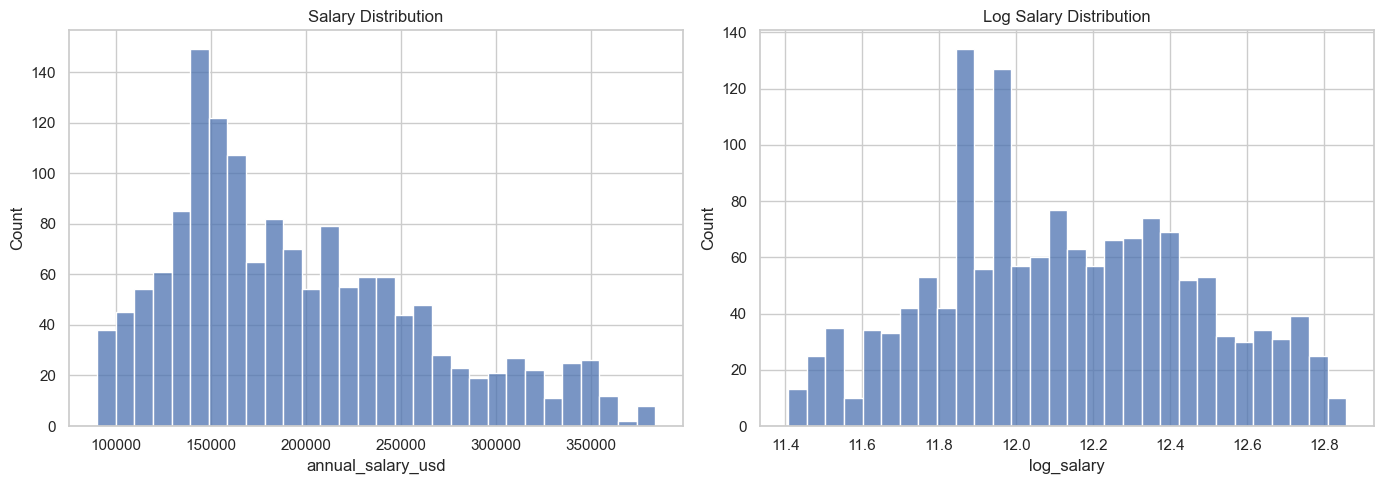

In [6]:
# compare raw salary to log salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=data, x='annual_salary_usd', bins=30, ax=axes[0])
axes[0].set_title('Salary Distribution')
sns.histplot(data=data, x='log_salary', bins=30, ax=axes[1])
axes[1].set_title('Log Salary Distribution')
plt.tight_layout()


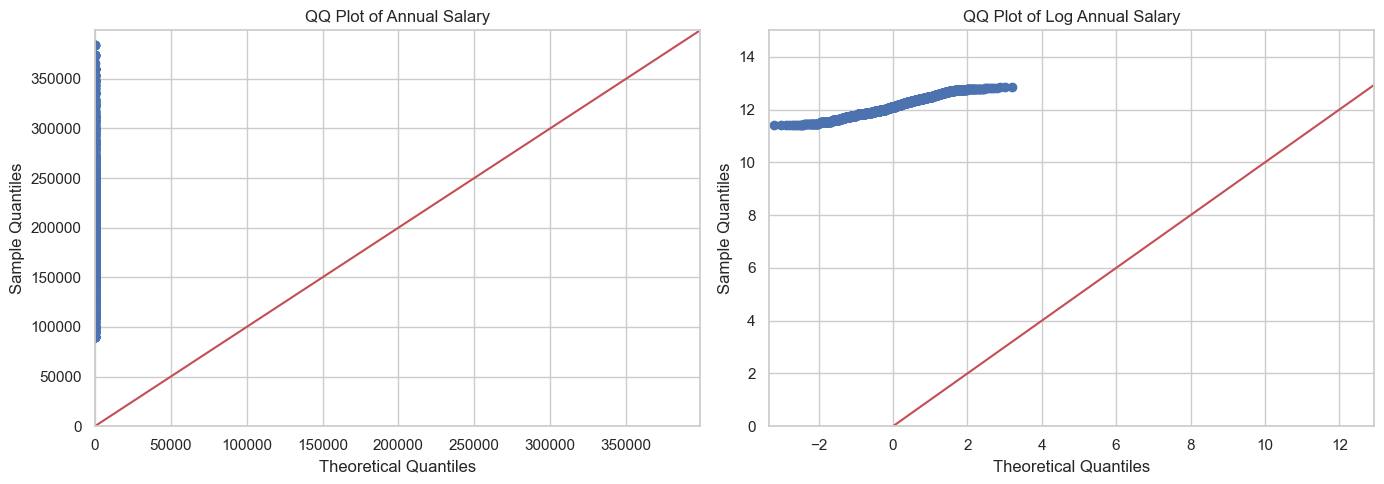

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
salaryqq = sm.qqplot(data['annual_salary_usd'], line = '45', ax = axes[0])
axes[0].set_title('QQ Plot of Annual Salary')
salaryqq = sm.qqplot(data['log_salary'], line = '45', ax = axes[1])
axes[1].set_title('QQ Plot of Log Annual Salary')
axes[1].set_ylim(top=15, bottom = 0)
plt.tight_layout()

The QQ plot of annual salary confirms that it is not normally distributed. Some extreme salary values in the right tail at the > $350,000 range are making the data highly right skewed.

Log transforming the data produced more of a normal distribution. The mean is higher than 0, which is why the points fall to the left of the 45 degree line, and the slope is flatter than 1 now, due to lower variance in the log salary than the standard normal distribution. Since using the log of salary makes an improvement for normal distribution, we will use the log version for our linear regression analysis.

### Salary Comparisons by Variables

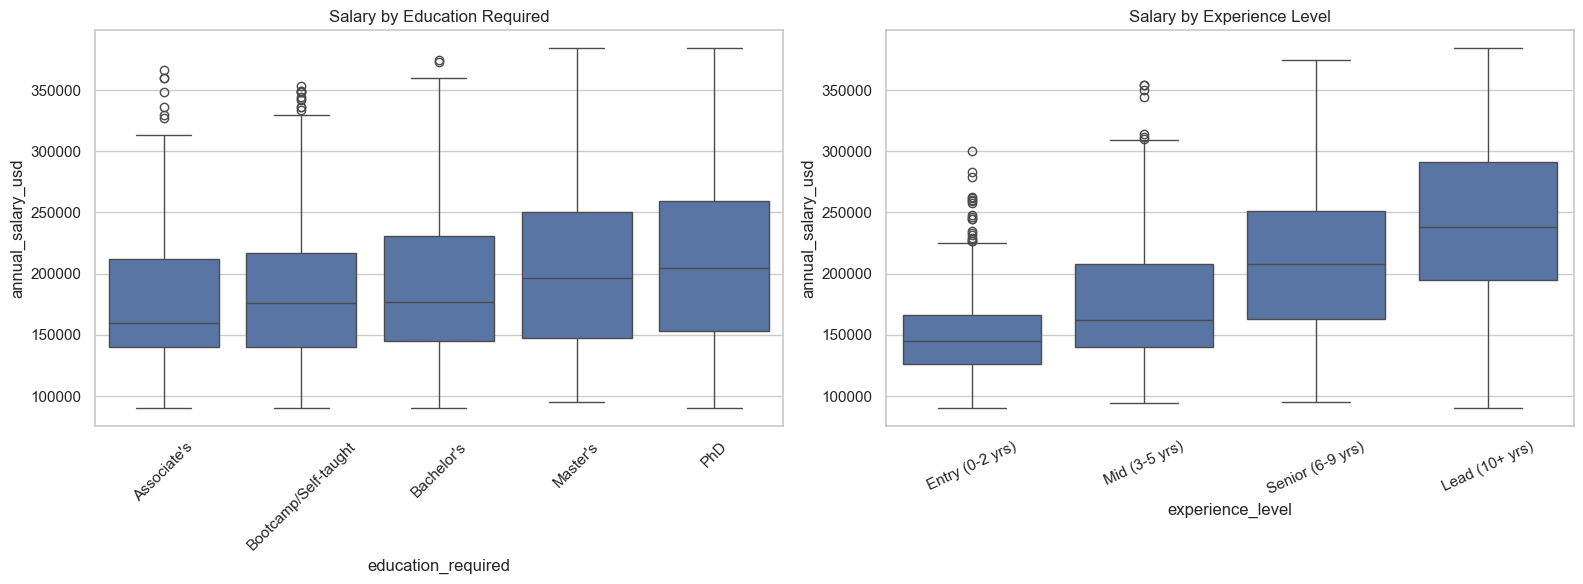

In [6]:
# boxplots for some main group comparisons
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
edu_order = data.groupby('education_required')['annual_salary_usd'].median().sort_values().index
exp_order = data.groupby('experience_level')['annual_salary_usd'].median().sort_values().index
sns.boxplot(data=data, x='education_required', y='annual_salary_usd', order=edu_order, ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Salary by Education Required')
sns.boxplot(data=data, x='experience_level', y='annual_salary_usd', order=exp_order, ax=axes[1])
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_title('Salary by Experience Level')
plt.tight_layout()


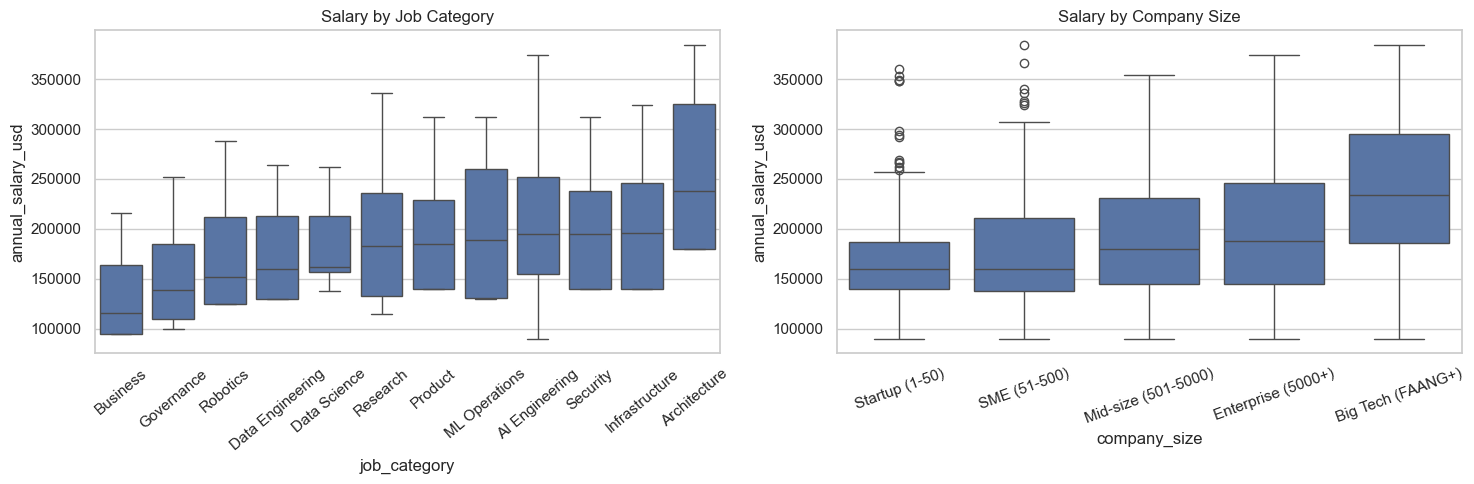

In [11]:
# more salary comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

job_order = data.groupby('job_category')['annual_salary_usd'].median().sort_values().index
company_order = data.groupby('company_size')['annual_salary_usd'].median().sort_values().index
sns.boxplot(data=data, x='job_category', y='annual_salary_usd', order=job_order, ax=axes[0])
axes[0].set_title('Salary by Job Category')
axes[0].tick_params(axis = 'x', rotation = 40)
sns.boxplot(data=data, x='company_size', y='annual_salary_usd', order=company_order, ax=axes[1])
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_title('Salary by Company Size')
plt.tight_layout()


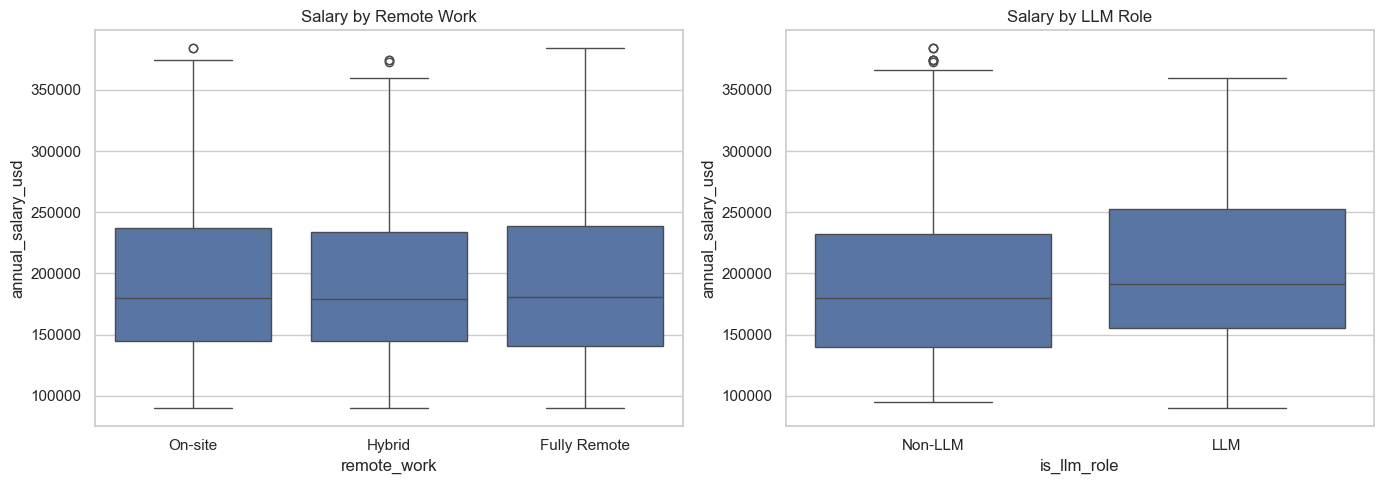

In [11]:
# remote and llm roles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='remote_work', y='annual_salary_usd', ax=axes[0])
axes[0].set_title('Salary by Remote Work')
sns.boxplot(data=data, x='is_llm_role', y='annual_salary_usd', ax=axes[1])
axes[1].set_title('Salary by LLM Role')
axes[1].set_xticklabels(['Non-LLM', 'LLM'])
plt.tight_layout()


### Grouped summaries.


In [13]:
# average and median salary by education
data.groupby('education_required')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
education_required,,,
PhD,280,213252.14,204500.0
Master's,316,205805.70,196500.0
Bachelor's,311,192321.54,177000.0
Bootcamp/Self-taught,297,187002.02,176000.0
Associate's,296,176490.54,160000.0


In [14]:
# average and median salary by remote work
data.groupby('remote_work')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
remote_work,,,
Fully Remote,445,197967.19,181000.0
On-site,369,195268.83,180000.0
Hybrid,686,192694.46,179000.0


In [15]:
# average and median salary by industry
data.groupby('industry')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2).head(10)


,count,mean,median
industry,,,
Automotive,138,212305.80,210500.0
Consulting,126,199328.57,189000.0
Finance,131,196824.43,185000.0
Healthcare,138,196188.41,180000.0
Retail,131,195360.31,183000.0
Government,136,195029.41,185500.0
Manufacturing,114,194514.04,180000.0
Research,110,193909.09,176500.0
Technology,106,192864.15,175500.0


In [12]:
# average and median salary by category
data.groupby('job_category')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
job_category,,,
Architecture,52,251576.92,238000.0
AI Engineering,736,207982.34,194500.0
Infrastructure,55,203527.27,196000.0
Security,50,200400.00,194500.0
ML Operations,51,199215.69,189000.0
Product,70,194571.43,185000.0
Research,50,192280.00,183000.0
Data Science,127,181275.59,162000.0
Data Engineering,51,176156.86,160000.0


In [38]:
data.groupby('job_title')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
job_title,,,
AI Solutions Architect,52,251576.92,238000.0
Senior ML Engineer,64,247953.12,227000.0
LLM Engineer,75,240960.00,232000.0
AI Agent Developer,57,225649.12,209000.0
Multimodal AI Engineer,67,221791.04,209000.0
RAG Engineer,53,218226.42,215000.0
NLP Engineer,55,210854.55,180000.0
Computer Vision Engineer,46,209173.91,201000.0
Generative AI Engineer,71,206760.56,177000.0


In [37]:
# average and median salary by country
data.groupby('city')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2).head(10)

,count,mean,median
city,,,
New York,67,248659.70,242000.0
San Francisco,92,240521.74,233500.0
Seattle,69,230544.93,221000.0
Remote,82,222043.90,221000.0
Chicago,77,219511.69,213000.0
Boston,70,219400.00,206500.0
Los Angeles,63,216184.13,210000.0
Austin,77,206649.35,197000.0
Dubai,62,194225.81,186500.0


### Location and ranking views.


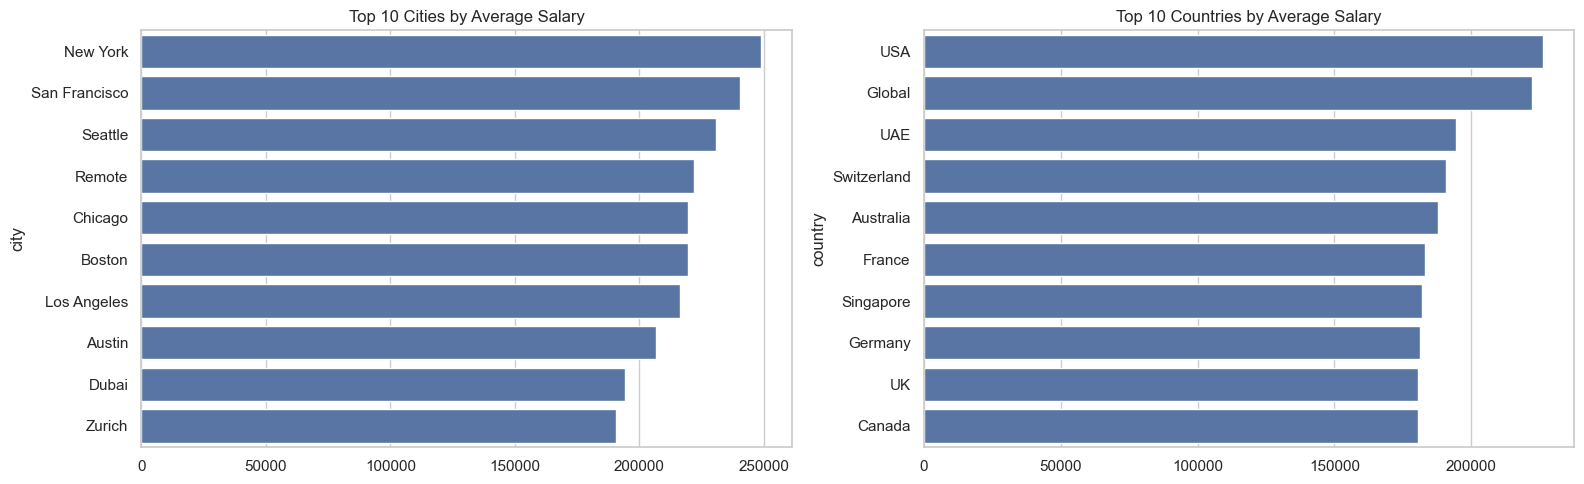

In [16]:
# top cities and industries by average salary
top_cities = data.groupby('city')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)
top_countries = data.groupby('country')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0])
axes[0].set_title('Top 10 Cities by Average Salary')
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1])
axes[1].set_title('Top 10 Countries by Average Salary')
plt.tight_layout()


New York has the highest mean salary out of all the cities. USA has the highest mean salary out of the countries. Remote jobs appear to be high paying, as remote is high in the rankings in cities.

In [26]:
data[(data['country'] == "Global")]['remote_work'].value_counts()

remote_work
Hybrid          42
Fully Remote    22
On-site         18
Name: count, dtype: int64

Checking the Global category of country revealed that a global job is not necessarily a remote job, so global salary is not representative of remote work.

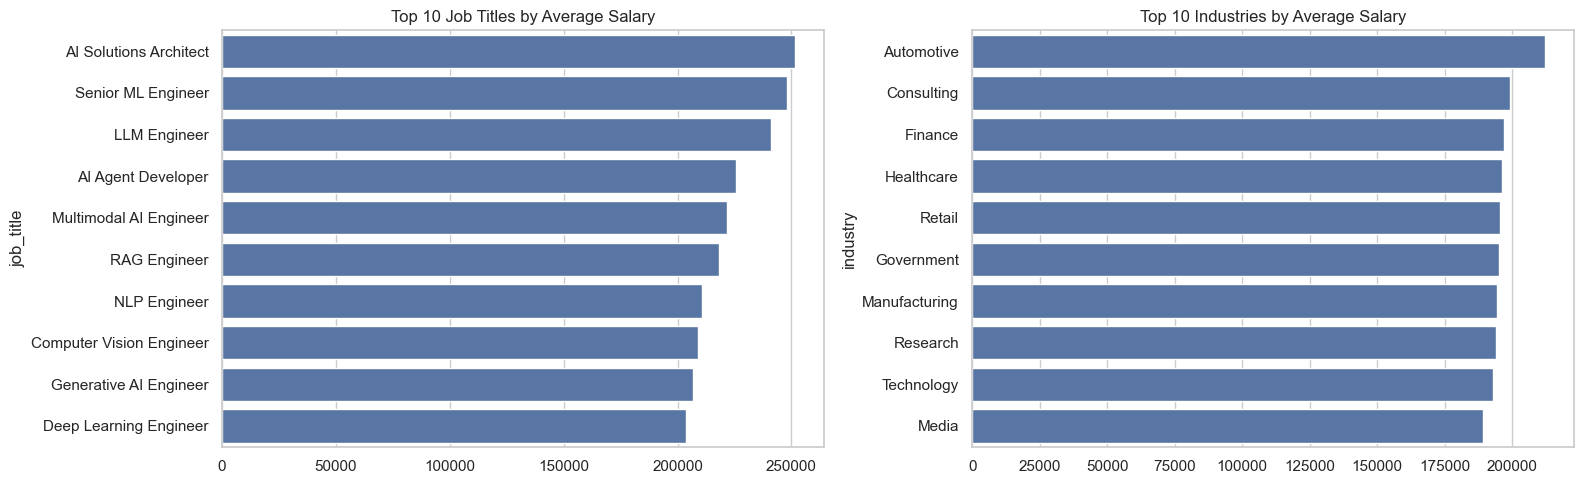

In [14]:
# top cities and industries by average salary
top_titles = data.groupby('job_title')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)
top_industries = data.groupby('industry')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, ax=axes[0])
axes[0].set_title('Top 10 Job Titles by Average Salary')
sns.barplot(x=top_industries.values, y=top_industries.index, ax=axes[1])
axes[1].set_title('Top 10 Industries by Average Salary')
plt.tight_layout()

### Relationships between variables.


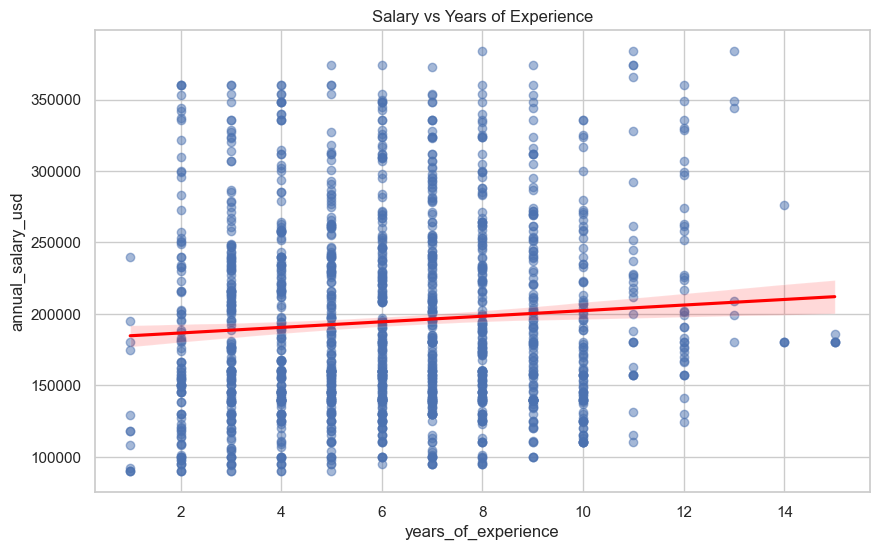

In [18]:
# salary and years of experience
sns.regplot(data=data, x='years_of_experience', y='annual_salary_usd', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Salary vs Years of Experience')
plt.show()


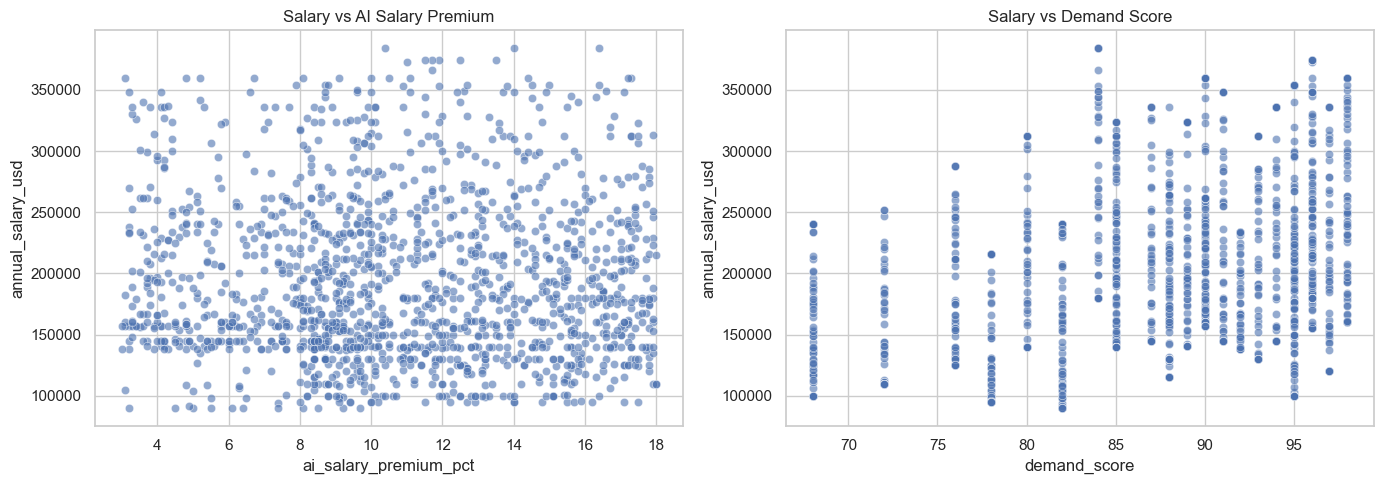

In [19]:
# salary and other numeric measures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=data, x='ai_salary_premium_pct', y='annual_salary_usd', alpha=0.6, ax=axes[0])
axes[0].set_title('Salary vs AI Salary Premium')
sns.scatterplot(data=data, x='demand_score', y='annual_salary_usd', alpha=0.6, ax=axes[1])
axes[1].set_title('Salary vs Demand Score')
plt.tight_layout()


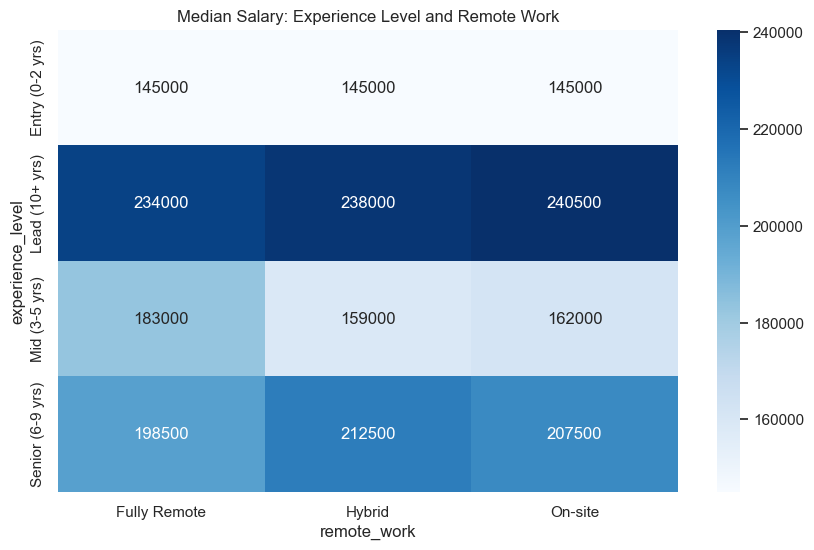

In [20]:
# median salary by experience level and remote work
remote_exp = pd.pivot_table(data, values='annual_salary_usd', index='experience_level', columns='remote_work', aggfunc='median')
sns.heatmap(remote_exp, annot=True, fmt='.0f', cmap='Blues')
plt.title('Median Salary: Experience Level and Remote Work')
plt.show()


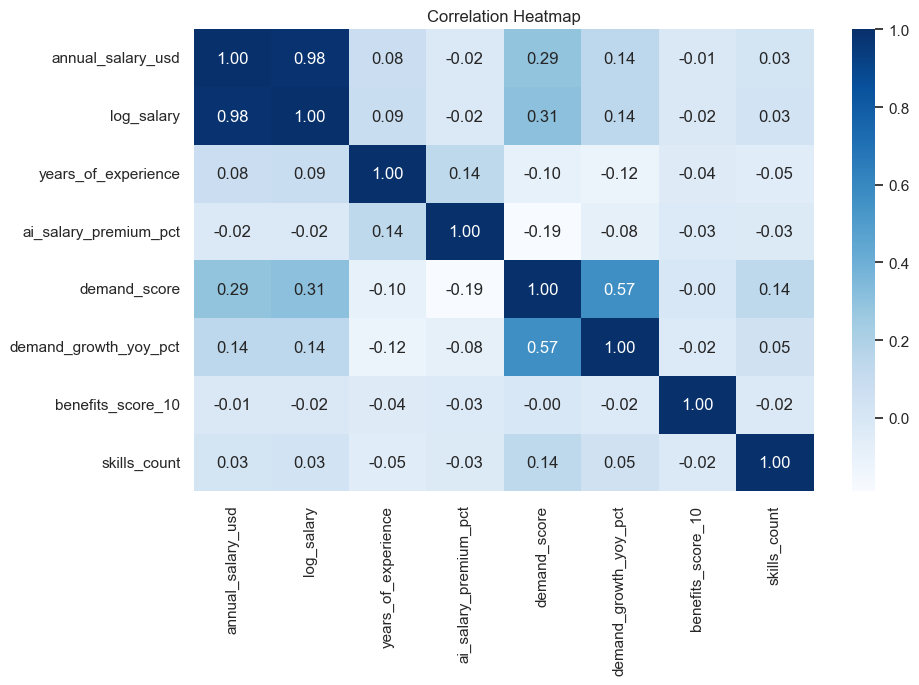

In [21]:
# correlations among numeric variables
corr_cols = ['annual_salary_usd', 'log_salary', 'years_of_experience', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'skills_count']
corr = data[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Check for Multicollinearity

In [5]:
# Model with all variables

all_model = smf.ols(data = data, formula = 'annual_salary_usd ~ job_category + job_title + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + ai_salary_premium_pct + demand_score + demand_growth_yoy_pct + benefits_score_10 + posting_year + posting_month + is_senior + is_remote_friendly + is_llm_role').fit()
print(all_model.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_salary_usd   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     142.9
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:32:02   Log-Likelihood:                -17309.
No. Observations:                1500   AIC:                         3.474e+04
Df Residuals:                    1437   BIC:                         3.508e+04
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [6]:
#Check for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
exog = all_model.model.exog
names = all_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: job_category[T.Architecture]:  inf
VIF: job_category[T.Business]:  inf
VIF: job_category[T.Data Engineering]:  inf
VIF: job_category[T.Data Science]:  inf
VIF: job_category[T.Governance]:  inf
VIF: job_category[T.Infrastructure]:  inf
VIF: job_category[T.ML Operations]:  inf
VIF: job_category[T.Product]:  inf
VIF: job_category[T.Research]:  inf
VIF: job_category[T.Robotics]:  inf
VIF: job_category[T.Security]:  inf
VIF: job_title[T.AI Business Analyst]:  inf
VIF: job_title[T.AI Compliance Manager]:  inf
VIF: job_title[T.AI Engineer]:  inf
VIF: job_title[T.AI Ethics Officer]:  inf
VIF: job_title[T.AI Infrastructure Eng]:  inf
VIF: job_title[T.AI Product Manager]:  inf
VIF: job_title[T.AI Research Scientist]:  inf
VIF: job_title[T.AI Security Engineer]:  inf
VIF: job_title[T.AI Solutions Architect]:  inf
VIF: job_title[T.Computer Vision Engineer]:  inf
VIF: job_title[T.Data Engineer (AI)]:  inf
VIF: job_title[T.Data Scientist]:  inf
VIF: job_title[T.Deep Learning Engineer]:  inf
VIF

There are a handful of variables that are duplicative of each other, as indicated by VIF scores of infinity. `demand_score`,  `is_llm_role`,  `job_category`,`job_title`, `experience_level`, `city`, `country`, `remote_work` (On-site), `is_senior`, and `is_remote_friendly` have VIFs of infinity. This suggests that 
- `job_category`and `job_title` are correlated with each other
- `experience_level` and `is_senior` are correlated with each other
- `city` and `country` are correlated with each other
-  `is_remote_friendly` and `remote_work` are correlated with each other.
-  `is_llm_role` may be correlated with `job_title`

It is unclear what variable `demand_score` is multicollinear with. It may also be `job_title`. 


Check that VIF drops when removing variables with multicollinearity.

In [12]:
# removed job_category
#removed is_senior (kept experience_level and years_of_experience)
#removed is_remote_friendly
#removed country
new_covars = ['job_title','experience_level','years_of_experience', 
'education_required', 'city' , 'remote_work' , 'company_size',
'ai_salary_premium_pct' , 'demand_score', 'demand_growth_yoy_pct' ,
'benefits_score_10', 'posting_year','posting_month']

new_formula = f'annual_salary_usd ~ {" + ".join(new_covars)}'
new_model = smf.ols(data = data, formula = new_formula).fit()


exog = new_model.model.exog
names = new_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: job_title[T.AI Business Analyst]:  inf
VIF: job_title[T.AI Compliance Manager]:  inf
VIF: job_title[T.AI Engineer]:  inf
VIF: job_title[T.AI Ethics Officer]:  inf
VIF: job_title[T.AI Infrastructure Eng]:  inf
VIF: job_title[T.AI Product Manager]:  inf
VIF: job_title[T.AI Research Scientist]:  inf
VIF: job_title[T.AI Security Engineer]:  inf
VIF: job_title[T.AI Solutions Architect]:  inf
VIF: job_title[T.Computer Vision Engineer]:  inf
VIF: job_title[T.Data Engineer (AI)]:  inf
VIF: job_title[T.Data Scientist]:  inf
VIF: job_title[T.Deep Learning Engineer]:  inf
VIF: job_title[T.Generative AI Engineer]:  inf
VIF: job_title[T.LLM Engineer]:  inf
VIF: job_title[T.ML Engineer]:  inf
VIF: job_title[T.MLOps Engineer]:  inf
VIF: job_title[T.Multimodal AI Engineer]:  inf
VIF: job_title[T.NLP Engineer]:  inf
VIF: job_title[T.Prompt Engineer]:  inf
VIF: job_title[T.RAG Engineer]:  inf
VIF: job_title[T.Robotics Engineer (AI)]:  inf
VIF: job_title[T.Senior Data Scientist]:  inf
VIF: job_title

When removing `is_llm_role`, `job_title` is still multicollinear with `demand_score`. Remove `demand_score` and check that VIFs drop.

In [14]:
final_no_multicol = ['job_title','experience_level','years_of_experience', 
'education_required', 'city' , 'remote_work' , 'company_size',
'ai_salary_premium_pct' , 'demand_growth_yoy_pct' ,
'benefits_score_10', 'posting_year','posting_month']

new_formula = f'annual_salary_usd ~ {" + ".join(final_no_multicol)}'
new_model = smf.ols(data = data, formula = new_formula).fit()


exog = new_model.model.exog
names = new_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: job_title[T.AI Business Analyst]:  2.256
VIF: job_title[T.AI Compliance Manager]:  2.386
VIF: job_title[T.AI Engineer]:  2.094
VIF: job_title[T.AI Ethics Officer]:  2.264
VIF: job_title[T.AI Infrastructure Eng]:  2.152
VIF: job_title[T.AI Product Manager]:  2.487
VIF: job_title[T.AI Research Scientist]:  2.124
VIF: job_title[T.AI Security Engineer]:  2.074
VIF: job_title[T.AI Solutions Architect]:  2.313
VIF: job_title[T.Computer Vision Engineer]:  2.156
VIF: job_title[T.Data Engineer (AI)]:  2.025
VIF: job_title[T.Data Scientist]:  2.272
VIF: job_title[T.Deep Learning Engineer]:  2.486
VIF: job_title[T.Generative AI Engineer]:  2.197
VIF: job_title[T.LLM Engineer]:  2.557
VIF: job_title[T.ML Engineer]:  1.989
VIF: job_title[T.MLOps Engineer]:  1.897
VIF: job_title[T.Multimodal AI Engineer]:  2.385
VIF: job_title[T.NLP Engineer]:  2.187
VIF: job_title[T.Prompt Engineer]:  2.714
VIF: job_title[T.RAG Engineer]:  2.143
VIF: job_title[T.Robotics Engineer (AI)]:  2.494
VIF: job_title[T

With the correlated variables removed, none of the VIFs of the remaining variables are high. 

In summary, to resolve the issue of multicollinearity for our multivariable linear model:
- We will only use job title and not job category, as job title is the more informative and direct version of the two
- We will not use demand_score (demand_growth_yoy_pct is still a measure of market demand) or is_llm_role because they were multicolinnear with job_title
- We will not use city and country in the same model
- We will not include is_senior, as it is a dummy variable serving as a duplicate of the senior category of the experience_level variable.
- We will use remote_work and not use remote_friendly, since remote_friendly is a binary version of remote_work encoding Hybrid/Remote vs in person.